# Артемьев М.О. ЕТ-128
# Практическая работа 6. Случайный лес.
## 1. Выполните классификацию набора данных из задания о Байесовской классификации с помощью случайного леса, варьируя количество участников ансамбля (от 50 до 100 с шагом 10).
## 2. Вычислите показатели качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера. Выполните визуализацию полученных результатов в виде диаграмм. Нанесите на диаграммы соответствующие значения, полученные в заданиях о Байесовской классификации, деревьях решений и бэггинге.
## 3. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
### - формулировка задания; 
### - гиперссылка на каталог репозитория с исходными текстами, набором данных и др. сопутствующими материалами;
### - рисунки с результатами визуализации; 
### - пояснения, раскрывающие смысл полученных результатов.

## Библиотеки

In [1]:
# Подключение библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Загрузка данных

In [2]:
# Загрузка датасета
beans = fetch_ucirepo(id=602)

# Признаки и целевая переменная
X = beans.data.features
y = beans.data.targets.squeeze()

feat_names = list(X.columns)
tag_names = [str(x) for x in sorted(y.unique())]

# Краткий вывод информации о данных
print("Размерность X:", X.shape)
print("Размерность y:", y.shape)
print("Названия признаков:", feat_names)
print("Названия классов:", tag_names)

Размерность X: (13611, 16)
Размерность y: (13611,)
Названия признаков: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']
Названия классов: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


## Параметры

In [3]:
ens_val = list(range(50, 101, 10)) # Диапазон участников ансамбля
train_val = list(range(60, 95, 5)) # Доли обучающей выборки

# Список метрик
metric_plot = [
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1")
]

random_state = 2026
best_depth = 9 # глубина дерева

## Обучение и оценивание

In [4]:
# Функция обучения модели и вычисления метрик качества
# Вход:
# model - классификатор, X_train, y_train - обучающая выборка, X_test, y_test - тестовая выборка
# Выход:
# scores - словарь с метриками accuracy, precision, recall, f1
def training_assestement(model, X_train, X_test, y_train, y_test):
    # Обучение модели
    model.fit(X_train, y_train)

    # Получение предсказаний
    y_pred = model.predict(X_test)

    # Расчет основных метрик
    scores = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="macro", zero_division=0)
    }

    return scores

## Подбор гиперпараметров случайного леса

In [5]:
# Разбиение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

# Результаты перебора
rf_results = []

# Перебираемые значения
max_samples_val = [0.5, 0.7, 1.0]
max_features_val = [0.5, 0.7, 1.0]

# Перебор значений
for max_s in max_samples_val:
    for max_f in max_features_val:
        for n_estimators in ens_val:
            # Создание случайного леса
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                criterion="gini",
                max_depth=best_depth,
                max_samples=max_s,
                max_features=max_f,
                bootstrap=True,
                random_state=random_state
            )

            # Обучение модели и получение метрик
            scores = training_assestement(model, X_train, X_test, y_train, y_test)

            # Сохранение результатов
            rf_results.append({
                "n_estimators": n_estimators,
                "max_samples": max_s,
                "max_features": max_f,
                **scores
            })

# Таблица результатов
rfdf = pd.DataFrame(rf_results)
rfdf = rfdf.sort_values(["max_samples", "max_features", "n_estimators"]).reset_index(drop=True)

print("Перебор параметров случайного леса:")
print(rfdf.round(4).to_string(index=False))

Перебор параметров случайного леса:
 n_estimators  max_samples  max_features  accuracy  precision  recall     f1
           50          0.5           0.5    0.9240     0.9368  0.9345 0.9356
           60          0.5           0.5    0.9247     0.9379  0.9356 0.9367
           70          0.5           0.5    0.9254     0.9382  0.9353 0.9367
           80          0.5           0.5    0.9254     0.9379  0.9354 0.9366
           90          0.5           0.5    0.9232     0.9361  0.9339 0.9350
          100          0.5           0.5    0.9236     0.9362  0.9341 0.9352
           50          0.5           0.7    0.9232     0.9374  0.9342 0.9358
           60          0.5           0.7    0.9229     0.9375  0.9339 0.9357
           70          0.5           0.7    0.9218     0.9363  0.9329 0.9345
           80          0.5           0.7    0.9236     0.9375  0.9342 0.9358
           90          0.5           0.7    0.9254     0.9389  0.9358 0.9373
          100          0.5           0.7

## Усреднение результатов по max_samples и max_features

In [6]:
# Группировка результатов, вычисление среднего значения метрик
group_rfdf = (
    rfdf.groupby(["max_samples", "max_features"], as_index=False)[
        ["accuracy", "precision", "recall", "f1"]
    ]
    .mean()
    .sort_values(["f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("Средние результаты по max_samples и max_features:")
print(group_rfdf.round(4).to_string(index=False))

Средние результаты по max_samples и max_features:
 max_samples  max_features  accuracy  precision  recall     f1
         0.7           0.5    0.9258     0.9388  0.9361 0.9374
         0.5           0.5    0.9244     0.9372  0.9348 0.9360
         0.5           0.7    0.9235     0.9375  0.9343 0.9359
         1.0           0.5    0.9238     0.9372  0.9338 0.9355
         1.0           0.7    0.9230     0.9359  0.9333 0.9345
         0.7           0.7    0.9228     0.9360  0.9330 0.9345
         0.7           1.0    0.9229     0.9358  0.9324 0.9340
         0.5           1.0    0.9225     0.9355  0.9323 0.9338
         1.0           1.0    0.9203     0.9331  0.9306 0.9318


## Выбор лучших max_samples и max_features

In [7]:
# Лучшие параметры
best_rf = group_rfdf.iloc[0]

best_max_samples = float(best_rf["max_samples"])
best_max_features = float(best_rf["max_features"])

print("Лучшие параметры случайного леса:")
print("max_samples =", best_max_samples)
print("max_features =", best_max_features)

Лучшие параметры случайного леса:
max_samples = 0.7
max_features = 0.5


## Результаты лучшей пары параметров

In [8]:
# Лучшие значения
rdf_rf = rfdf[
    (rfdf["max_samples"] == best_max_samples) &
    (rfdf["max_features"] == best_max_features)
].sort_values("n_estimators").reset_index(drop=True)

print("Метрики качества случайного леса для лучших параметров:")
print(rdf_rf.round(4).to_string(index=False))

Метрики качества случайного леса для лучших параметров:
 n_estimators  max_samples  max_features  accuracy  precision  recall     f1
           50          0.7           0.5    0.9258     0.9392  0.9363 0.9378
           60          0.7           0.5    0.9258     0.9391  0.9361 0.9376
           70          0.7           0.5    0.9254     0.9386  0.9359 0.9372
           80          0.7           0.5    0.9243     0.9376  0.9350 0.9363
           90          0.7           0.5    0.9269     0.9395  0.9368 0.9381
          100          0.7           0.5    0.9266     0.9387  0.9366 0.9376


## Визуализация случайного леса

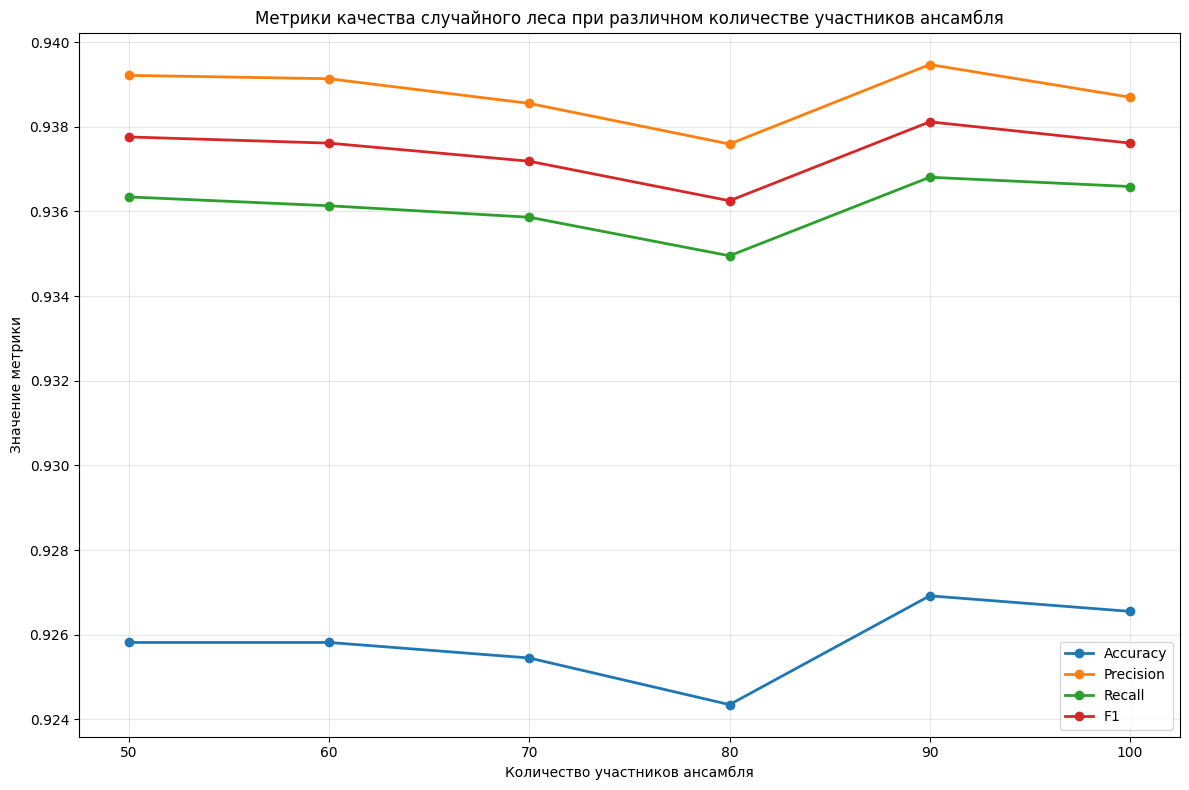

In [13]:
plt.figure(figsize=(12, 8))

for m, title in metric_plot:
    plt.plot(
        rdf_rf["n_estimators"],
        rdf_rf[m],
        marker="o",
        linewidth=2,
        label=title
    )

plt.title("Метрики качества случайного леса при различном количестве участников ансамбля")
plt.xlabel("Количество участников ансамбля")
plt.ylabel("Значение метрики")
plt.xticks(ens_val)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Сравнение случайного леса с прошлыми работами

In [10]:
# Список результатов
results = []

# Перебор количества ансамблей
for n_estimators_fr in ens_val:
    # Перебор доли обучающей выборки
    for train_fr in train_val:
        test_fr = 100 - train_fr

        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_fr / 100,
            random_state=random_state,
            stratify=y
        )

        # Набор сравниваемых моделей
        models = [
            ("Байес", GaussianNB()),
            ("Дерево (gini)", DecisionTreeClassifier(
                criterion="gini",
                max_depth=best_depth,
                random_state=random_state
            )),
            ("Дерево (gain)", DecisionTreeClassifier(
                criterion="entropy",
                max_depth=best_depth,
                random_state=random_state
            )),
            ("Бэггинг (gini)", BaggingClassifier(
                estimator=DecisionTreeClassifier(
                    criterion="gini",
                    max_depth=best_depth,
                    random_state=random_state
                ),
                n_estimators=n_estimators_fr,
                random_state=random_state
            )),
            ("Случайный лес", RandomForestClassifier(
                n_estimators=n_estimators_fr,
                criterion="gini",
                max_depth=best_depth,
                max_samples=best_max_samples,
                max_features=best_max_features,
                bootstrap=True,
                random_state=random_state
            ))
        ]

        # Обучение каждой модели
        for model_name, model in models:
            scores = training_assestement(model, X_train, X_test, y_train, y_test)

            results.append({
                "model": model_name,
                "n_estimators": n_estimators_fr if model_name in ["Бэггинг (gini)", "Случайный лес"] else "-",
                "train_fr": train_fr,
                "test_fr": test_fr,
                **scores
            })

# Таблица результатов
rdf = pd.DataFrame(results)

# Удаление дубликатов и сортировка
rdf = (
    rdf.drop_duplicates()
       .sort_values(["model", "n_estimators", "train_fr"])
       .reset_index(drop=True)
)

print("Итоговые результаты классификации:")
print(rdf.round(4).to_string(index=False))

Итоговые результаты классификации:
         model n_estimators  train_fr  test_fr  accuracy  precision  recall     f1
         Байес            -        60       40    0.7655     0.7706  0.7689 0.7681
         Байес            -        65       35    0.7649     0.7688  0.7680 0.7671
         Байес            -        70       30    0.7618     0.7636  0.7633 0.7626
         Байес            -        75       25    0.7617     0.7648  0.7651 0.7637
         Байес            -        80       20    0.7587     0.7625  0.7631 0.7619
         Байес            -        85       15    0.7595     0.7665  0.7649 0.7645
         Байес            -        90       10    0.7592     0.7645  0.7632 0.7627
Бэггинг (gini)           50        60       40    0.9218     0.9343  0.9317 0.9330
Бэггинг (gini)           50        65       35    0.9225     0.9357  0.9321 0.9339
Бэггинг (gini)           50        70       30    0.9241     0.9365  0.9326 0.9345
Бэггинг (gini)           50        75       25    0.

## Визуализация сравнения

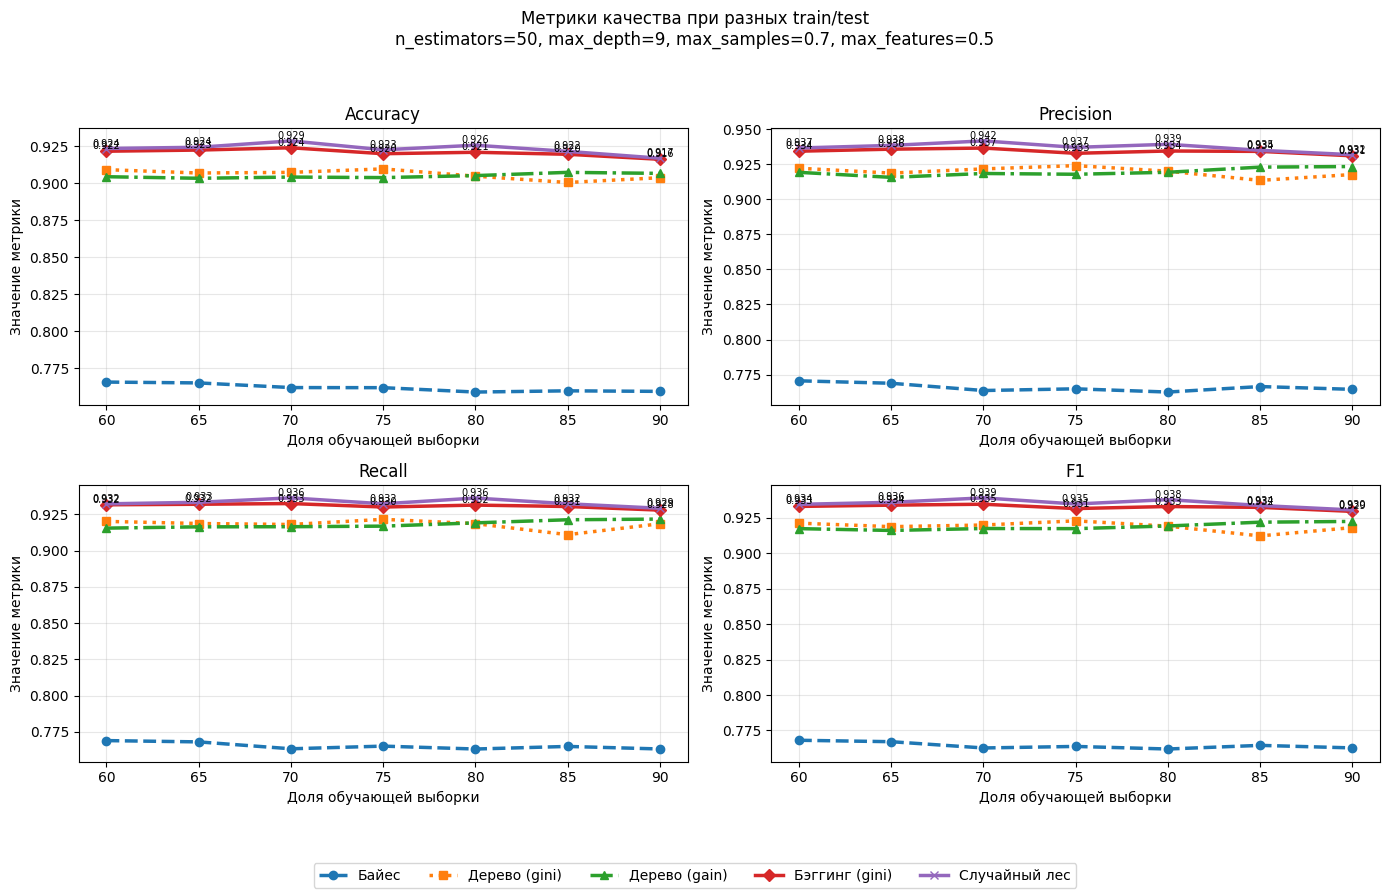

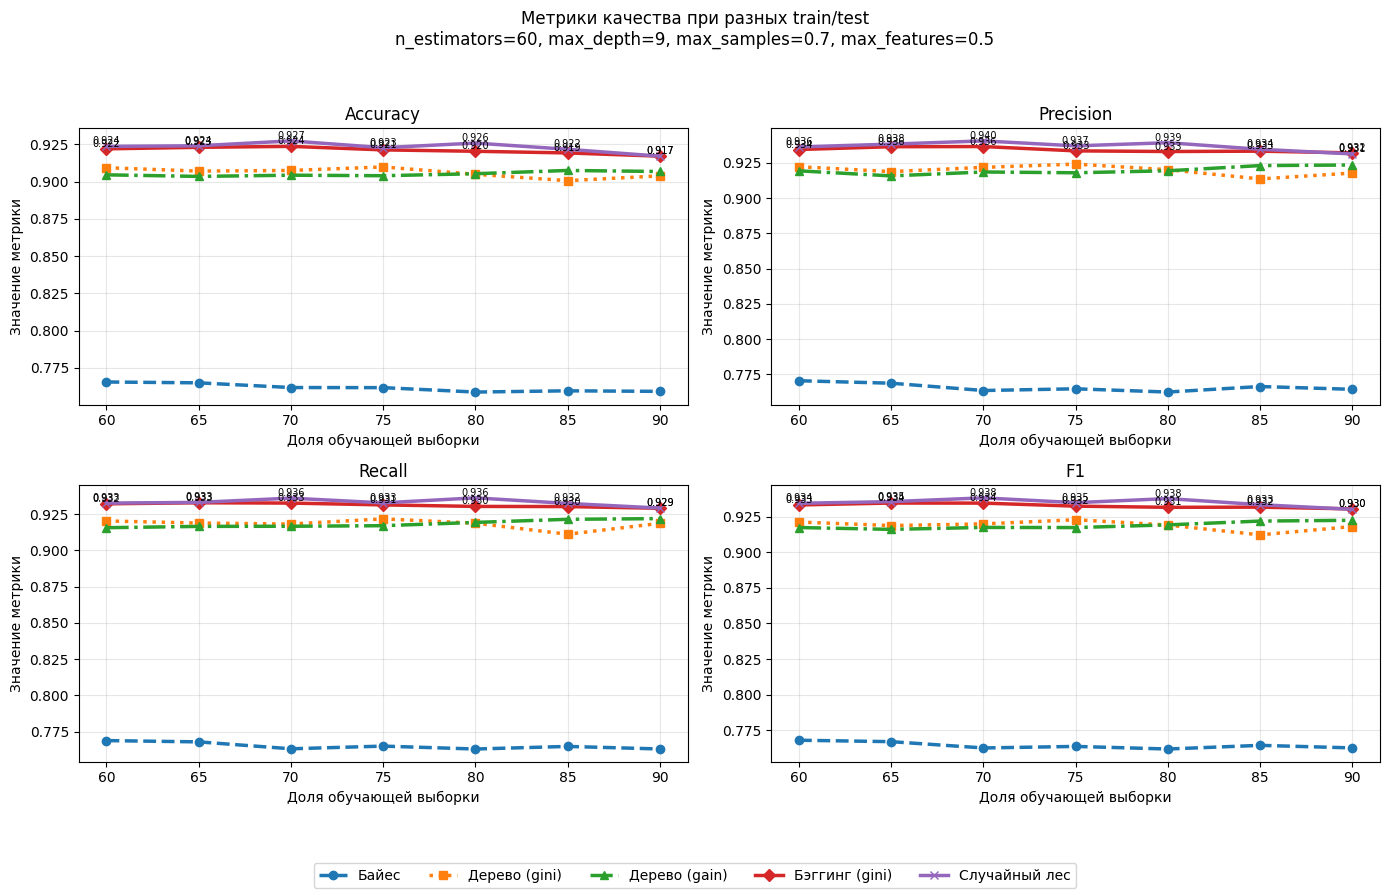

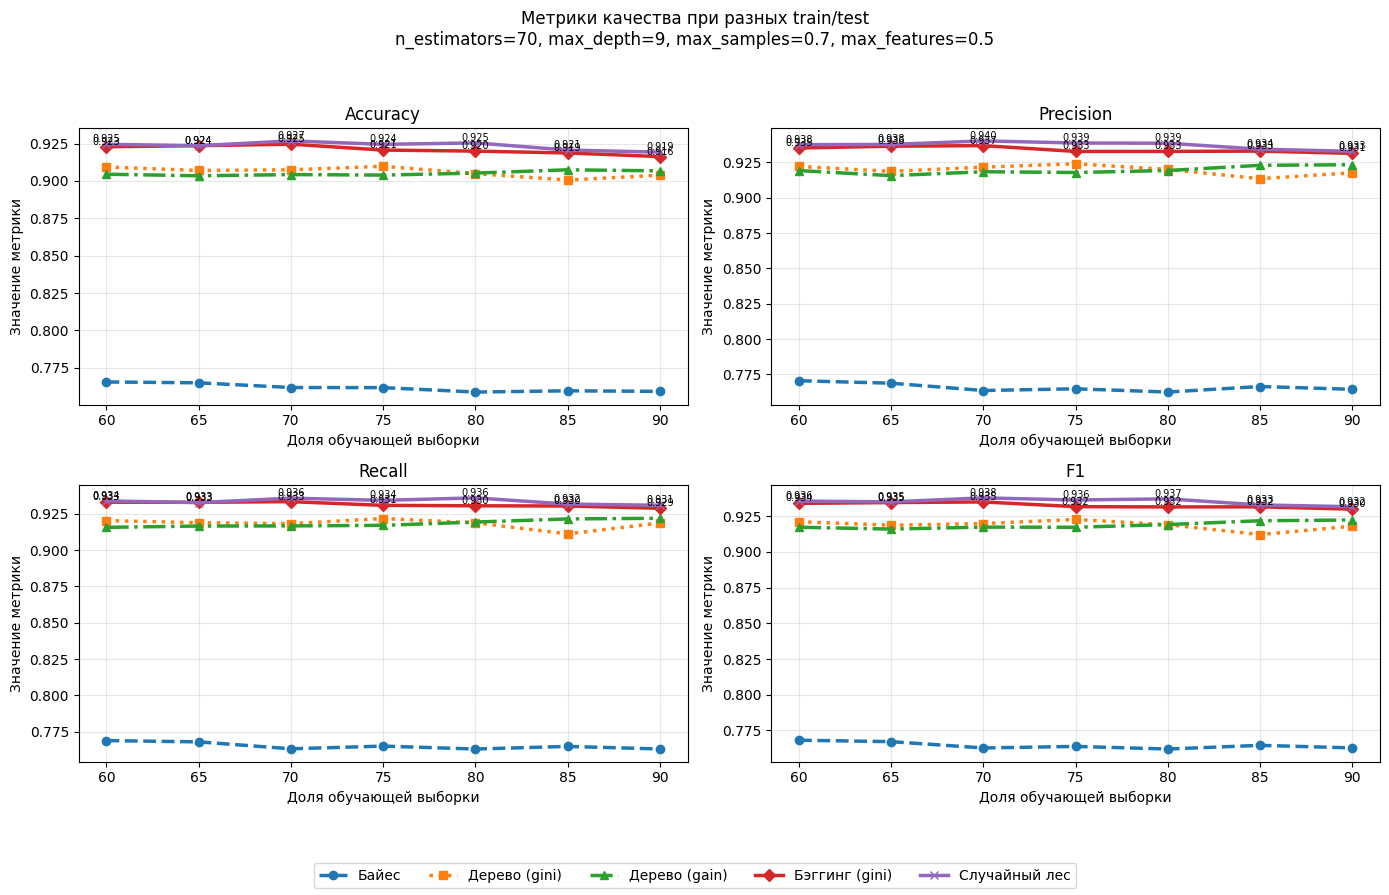

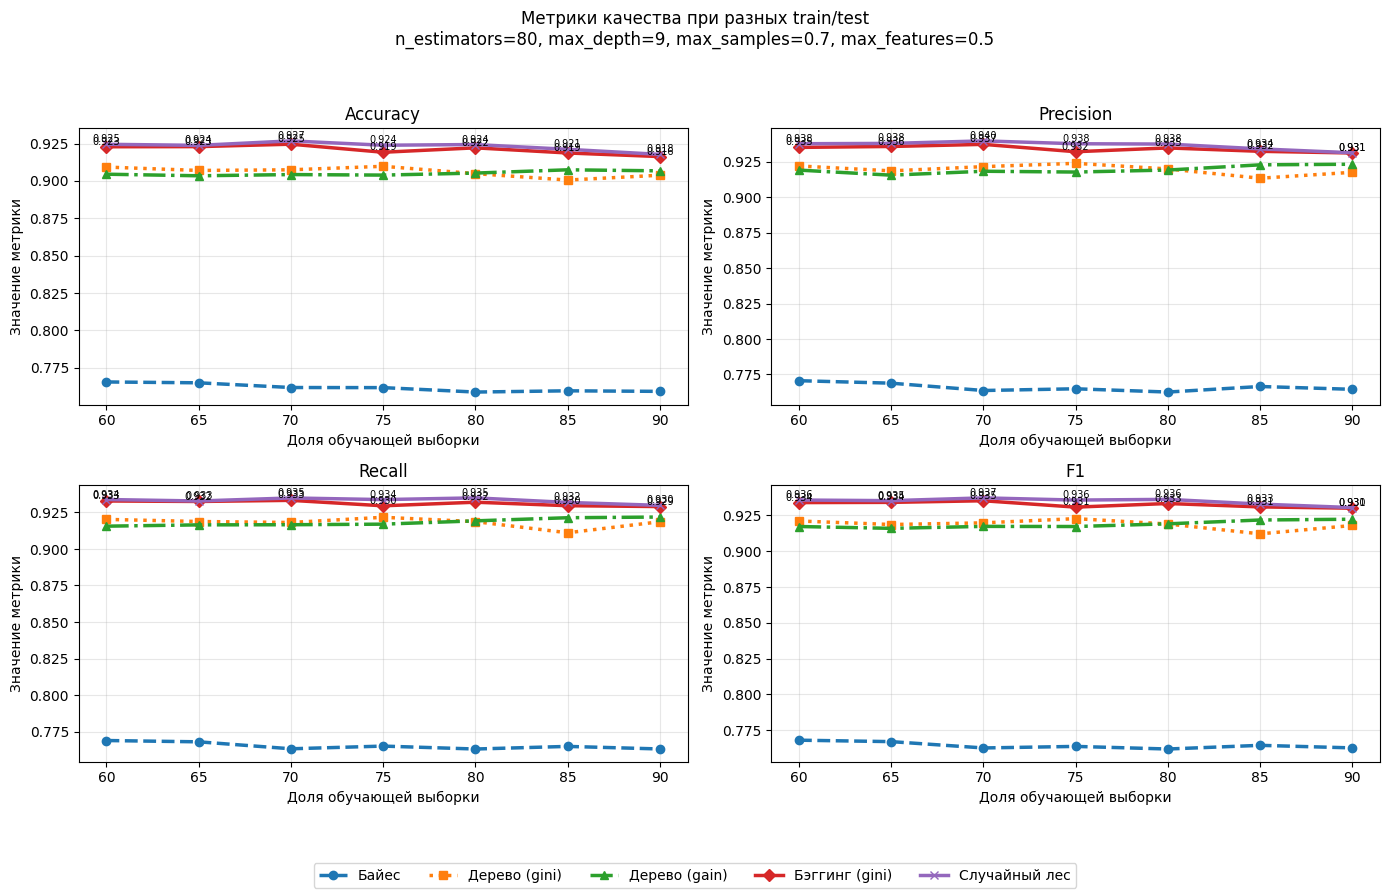

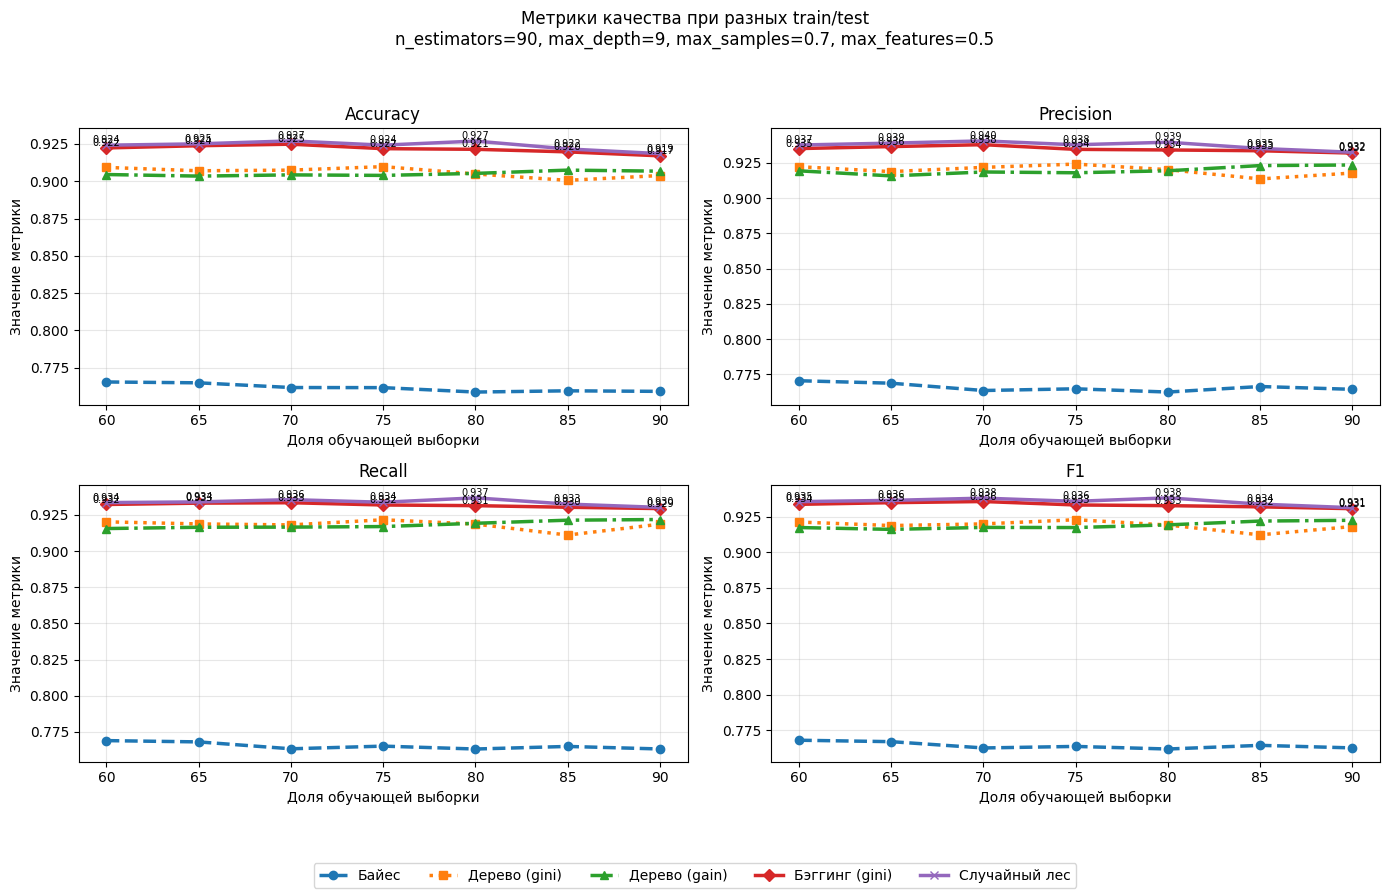

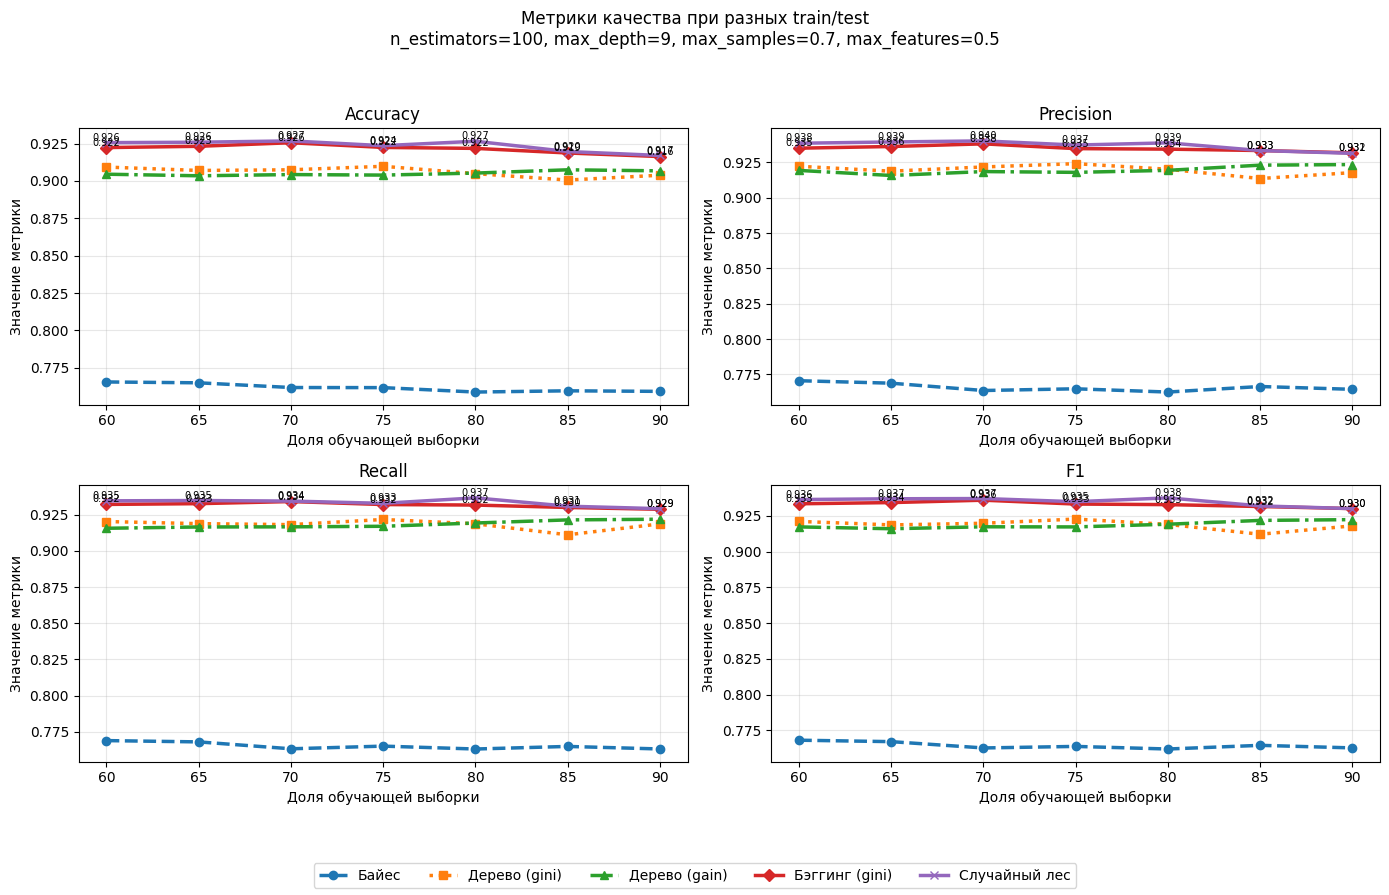

In [12]:
# Порядок отображения
models_order = ["Байес", "Дерево (gini)", "Дерево (gain)", "Бэггинг (gini)", "Случайный лес"]

model_style = {
    "Байес": {"linestyle": "--", "marker": "o"},
    "Дерево (gini)": {"linestyle": ":", "marker": "s"},
    "Дерево (gain)": {"linestyle": "-.", "marker": "^"},
    "Бэггинг (gini)": {"linestyle": "-", "marker": "D"},
    "Случайный лес": {"linestyle": "-", "marker": "x"},
}

# Для каждого значения количества ансамблей строим график
for n_estimators_fr in ens_val:
    fig, axs = plt.subplots(2, 2, figsize=(14, 9))
    axs = axs.ravel()

    for ax, (m, title) in zip(axs, metric_plot):
        for model_name in models_order:

            if model_name in ["Бэггинг (gini)", "Случайный лес"]:
                d = rdf[
                    (rdf["n_estimators"] == n_estimators_fr) &
                    (rdf["model"] == model_name)
                ].sort_values("train_fr")
            else:
                d = rdf[
                    rdf["model"] == model_name
                ].sort_values("train_fr")

            ax.plot(
                d["train_fr"],
                d[m],
                linewidth=2.5,
                label=model_name,
                **model_style[model_name]
            )

            # Подписи только для бэггинга и случайного леса
            if model_name in ["Бэггинг (gini)", "Случайный лес"]:
                for x, y_val in zip(d["train_fr"], d[m]):
                    ax.text(x, y_val, f"{y_val:.3f}", ha="center", va="bottom", fontsize=7)

        ax.set_title(title)
        ax.set_xlabel("Доля обучающей выборки")
        ax.set_ylabel("Значение метрики")
        ax.set_xticks(train_val)
        ax.grid(True, alpha=0.3)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=5)

    fig.suptitle(
        "Метрики качества при разных train/test\n"
        f"n_estimators={n_estimators_fr}, max_depth={best_depth}, "
        f"max_samples={best_max_samples}, max_features={best_max_features}"
    )

    fig.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()